# Matching halos across simulations

This tutorial compares particles from a matched halo between a gravity-only and a hydrodynamic simulation. 
- Match objects between halo catalogs
- Confirm particle overlap between the halo particles
- Plot and compare properties of the halos

<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Halo Properties</span>
    <span class="chip chip-data">Halo Particles</span>
    <span class="chip chip-data">Linked Datasets</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
  </div>
</div>

First, let's load the relevant libraries. We're using numpy, matplotlib, scipy and opencosmo - these will already be in your environment if you've set up the opencosmo toolkit. In particular we're using scipy's KDTree matching algorithm to help with teh object matching, abinned_statistic to help with making


In [1]:
import numpy as np
from matplotlib import pyplot as plt # for plotting 
from matplotlib.colors import LogNorm
from scipy.spatial import cKDTree # for matching
from scipy.stats import binned_statistic_2d


import opencosmo

> **Tip**
> 
> *Remember that particle-based data can be very large!*
> 
> We will first want to match the halos between the simulations using their position and/or mass before comparing their particle data. For an arbitrary halo, the easiest way of doing this is to find the matches using halo information only, and then request the particles solely of those halos using the data portal, as the whole set of particles is pretty big.
> 
>  In this case we instead work with a tiny catalog of haloparticle data covering only the most massive halos from each simulation, so we skip this step and work with a matched set of data instead. See [Collections](https://opencosmo.readthedocs.io/en/stable/collections.html) for more details. 


## Halo particles 

Here we load the dataset and see the collections, this is divided up into the different types of particles, in the hydro case this is:
- AGN (agn_particles)
- dark matter (dm_particles)
- gas (gas_particles) 
- stars (star_particles)

And for the gravity-only simulation we instead have:
- gravity-only particles (gravity_particles)
  
alongside the properties of the halo (halo_properties). The properties and the particle data are linked as a [Collection](https://opencosmo.readthedocs.io/en/stable/collection_ref.html) within the file.


<details>
<summary><b>Question - what is the difference between dm_particles and gravity_particles?</b></summary>


Gravity-only simulations use dark matter-like particles designed to track the total matter in the simulation with only the influence of gravity, but they take into account the baryonic mass and the total matter transfer function. True dark matter particles in hydrodynamic simulations are solely the dark matter component.

</details>


In [2]:
import opencosmo as oc
dataset_go = oc.open("haloparticles.hdf5")
dataset_hydro = oc.open("haloparticles_hydro.hdf5")
print(dataset_hydro)
print(dataset_go)


Collection of halos with agn_particles, dm_particles, gas_particles, star_particles, and halo_properties
Collection of halos with gravity_particles and halo_properties


## Matching between the datasets

To match between the datasets we use the property information to do an initial pass. We access this simply using, e.g. 

```
data_properties_hydro = dataset_hydro['halo_properties']

```

In [3]:
data_properties_hydro = dataset_hydro['halo_properties']
data_properties = dataset_go['halo_properties']

<details>
<summary><b>Tip - accessing metadata</b></summary>

You can get details on the columns, their descriptions, and the cosmology using the following attributes
 - data_properties.cosmology
 - data_properties.columns
 - data_properties.descriptions

</details>


At this point, we haven't loaded any actual data into memory. This is super useful when looking at large catalogs, and you'll almost always want to filter the data in some way before loading it to limit your memory usage.  

We can select only the columns we want using something like this
```
data_properties_hydro = data_properties_hydro.select([column1 ,column2, column3, ...])
```
and restrict data using filters using, e.g.
```
filter_mass = oc.col("fof_halo_mass") > 1e13
data_highmass = data_properties.filter(filter_mass).

```
You can do more complex operations, such as creating derived columns, as described here https://opencosmo.readthedocs.io/en/stable/cols.html


Here we're just going to select the spatial information, a tag we can use to define the halo, and the masses. Typically when you're comparing between gravity-only and hydro simulations you should compare spherical overdensity masses so we'll select 'sod_halo_mass', and in HACC the spherical overdensity middle point is taken from the fof halo center so we'll use 'fof_halo_center_xyz'.


We then get the data using the function
```
get_data(),
```
for which we can put a string argument of numpy, astropy, pandas, polars, or arrow to define the type of data you'd like returned. 

In [4]:
column_list = ['fof_halo_mass', 'fof_halo_center_x', 'fof_halo_center_y',
               'fof_halo_center_z', 'fof_halo_tag']

data_properties_hydro = data_properties_hydro.select(column_list)
data_properties = data_properties.select(column_list)

dict_props = data_properties.get_data('numpy') 
dict_props_hydro = data_properties_hydro.get_data('numpy') 




Now let's do a match-up. We'll do a 1Mpc radius for candidate matches, using a KDTree method from scipy. 

In [5]:
# catalog A
posA = np.vstack([dict_props['fof_halo_center_x'], dict_props['fof_halo_center_x'], dict_props['fof_halo_center_x']]).T
posB = np.vstack([dict_props_hydro['fof_halo_center_x'], dict_props_hydro['fof_halo_center_x'], dict_props_hydro['fof_halo_center_x']]).T

tree = cKDTree(posB)
dist, idx = tree.query(posA, k=1)

radius = 1.0
mask = dist < radius

matched_A = dict_props['fof_halo_tag'][mask]
matched_B = dict_props_hydro['fof_halo_tag'][idx[mask]]



<details>
<summary><b>Tip - understanding masses</b></summary>

Spherical overdensity algorithms look at properties of all particles in a spherical shell surrounding a center point, while friends-of-friends algorithms directly link dark-matter particles. For gravity-only simulations, these only differ by 5-10%, however for hydro simulations, you need to remember that dark-matter FOF algorithms exclude the baryonic mass. To compare those you would need to use the baryonic fraction, found in the cosmology, to get equivalent masses. 


</details>

And let's compare the first candidate match. First I'm going to see what the overlap between particle IDs is. What you need to know is that in HACC hydro simulations, the nested initial condition setup changes the particle IDs of the dark matter particles. You can recover the gravity-only equivalent simply using 

```
id_gravonly= (id_dm/2).astype(int)
```


In [6]:
def get_gravid(id_array):
    return (id_array/2).astype(int)
    

gravity_particles = dataset_go['gravity_particles'].filter(oc.col("fof_halo_tag") == matched_A[0]).get_data('numpy')
dm_particles = dataset_hydro['dm_particles'].filter(oc.col("fof_halo_tag") == matched_B[0]).get_data('numpy')


ids = get_gravid(dm_particles['id'])
mask_isin = np.isin(gravity_particles['id'], ids)

intersecting_particles = gravity_particles['id'][mask_isin]
non_intersecting_particles = gravity_particles['id'][~mask_isin]

print("Matching rate for dark matter particles = ", len(intersecting_particles)/len(ids))


Matching rate for dark matter particles =  0.9926340863255902


We found a >99% matching rate between the particles, so let's accept this match as a true matched halo. Now we can compare the data to our heart's content. 

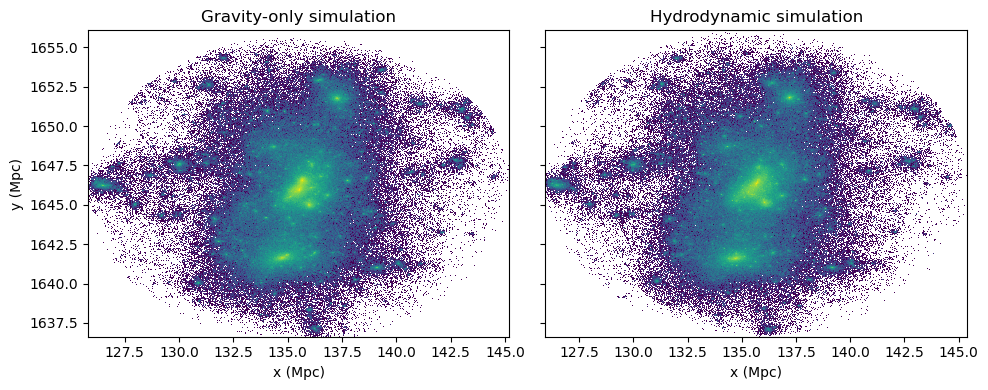

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

ax[0].hist2d(gravity_particles['x'],gravity_particles['y'],bins=1000,norm=LogNorm())
ax[0].set_title("Gravity-only simulation")
ax[0].set_xlabel('x (Mpc)')
ax[0].set_ylabel('y (Mpc)')

ax[1].hist2d(dm_particles['x'],dm_particles['y'],bins=1000,norm=LogNorm())
ax[1].set_title("Hydrodynamic simulation")
ax[1].set_xlabel('x (Mpc)')

plt.tight_layout()
plt.show()


We can also look at more properties of this data, if comparing between different hydro simulations we have more options but we'll limit for now to gravity-only comparisons, which we can find using 
```
dataset_go['gravity_particles'].columns
```
Let's weight our histograms at the gravitational potential, phi, and then at the x-direction velocity vx.

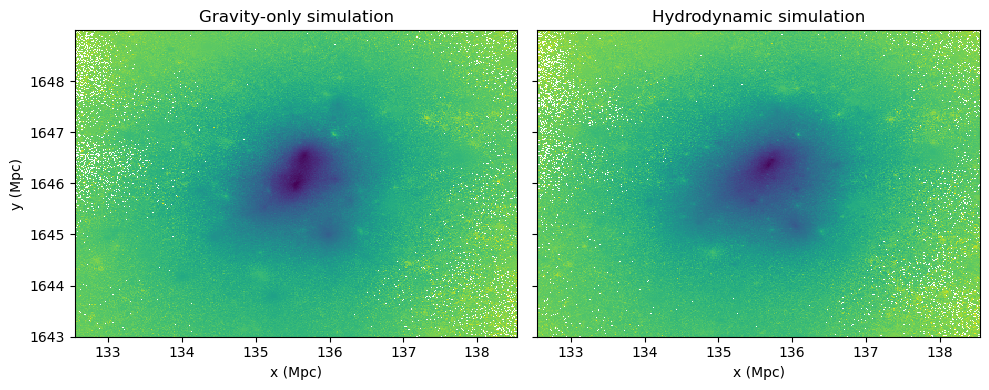

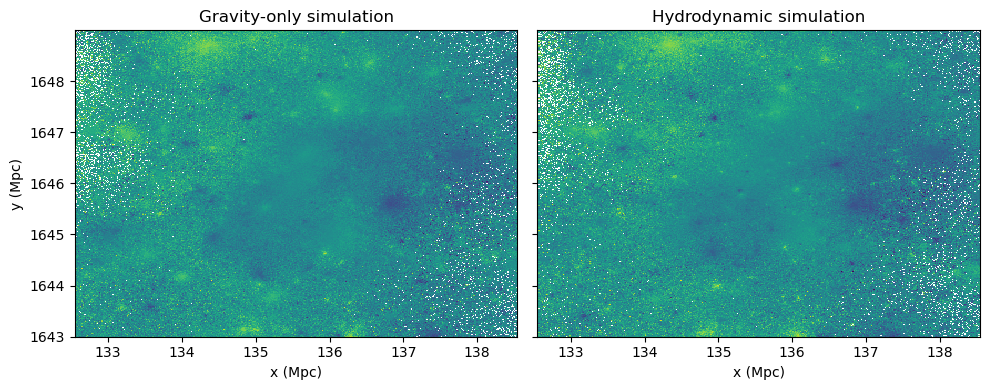

In [8]:
bin_center_x = dict_props['fof_halo_center_x'][mask][0]
bin_center_y = dict_props['fof_halo_center_y'][mask][0]
dx = 3.0
bins_zoom = [np.linspace(bin_center_x - dx, bin_center_x+dx,400),np.linspace(bin_center_y - dx, bin_center_y+dx,400)]


fig, ax = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

phi_mean, xedges, yedges, binnumber = binned_statistic_2d(gravity_particles['x'], gravity_particles['y'], gravity_particles['phi'], statistic="mean", bins=bins_zoom)
phi_mean_hydro, xedges_hydro, yedges_hydro, binnumber_hydro = binned_statistic_2d(dm_particles['x'], dm_particles['y'], dm_particles['phi'], statistic="mean", bins=bins_zoom)

ax[0].pcolormesh(xedges, yedges, phi_mean.T)
ax[0].set_title("Gravity-only simulation")
ax[0].set_xlabel('x (Mpc)')
ax[0].set_ylabel('y (Mpc)')

ax[1].pcolormesh(xedges_hydro, yedges_hydro, phi_mean_hydro.T)
ax[1].set_title("Hydrodynamic simulation")
ax[1].set_xlabel('x (Mpc)')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4),sharey=True)

vx_mean, xedges, yedges, binnumber = binned_statistic_2d(gravity_particles['x'], gravity_particles['y'], gravity_particles['vx'], statistic="mean", bins=bins_zoom)
vx_mean_hydro, xedges_hydro, yedges_hydro, binnumber_hydro = binned_statistic_2d(dm_particles['x'], dm_particles['y'], dm_particles['vx'], statistic="mean", bins=bins_zoom)

ax[0].pcolormesh(xedges, yedges, vx_mean.T)
ax[0].set_title("Gravity-only simulation")
ax[0].set_xlabel('x (Mpc)')
ax[0].set_ylabel('y (Mpc)')

ax[1].pcolormesh(xedges_hydro, yedges_hydro, vx_mean_hydro.T)
ax[1].set_title("Hydrodynamic simulation")
ax[1].set_xlabel('x (Mpc)')

plt.tight_layout()
plt.show()
